#  Build Model Predictor \


## B) Nguyên tắc chọn model cho web (đơn giản → phức tạp)
Tiêu chí chọn không chỉ là metric, mà còn:
- **Training time**: cần nhanh để iterate / retrain định kỳ  
- **Inference latency**: dự đoán nhanh cho request real-time  
- **Model size**: nhẹ để load nhanh & ít RAM  
- **Độ ổn định**: ít “nhảy” theo data mới

Chiến lược:
1) Baseline (Dummy)  
2) Linear model (Ridge / ElasticNet / Logistic)  
3) Linear online (SGD) cho high-dim, dữ liệu lớn  
4) Nếu vẫn thiếu: boosting/NN (optional), nhưng cân nhắc cost



## 1) Load data & quick audit
- Đọc dữ liệu
- Ép kiểu số cho các cột phổ biến
- Lọc dòng hợp lệ: `price>0`, `area>0` (nếu có `area`)


In [2]:
import numpy as np
import pandas as pd

PATH = "../../data/processed/data_clean.csv"
df = pd.read_csv(PATH)

for c in ["price","area","price_per_sqm","amenity_score","location_score","security_score",
          "near_school","near_market","near_supermarket"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

work = df.copy()
if "price" not in work.columns:
    raise ValueError("Dataset must contain 'price' column.")

if "area" in work.columns:
    work = work[(work["price"] > 0) & (work["area"] > 0)].copy()
else:
    work = work[(work["price"] > 0)].copy()

df.shape, work.shape


((28554, 34), (28554, 34))

**Nhận xét nhỏ:** `work` là dataset hợp lệ tối thiểu. Bước tiếp theo: define target + split.


## 2) Define targets (Regression + Classification)

### Regression target
- `y_reg = log1p(price)` để giảm lệch và giảm ảnh hưởng outlier.

### Classification target
- `y_cls = price_segment` (Low/Mid/High) dựa trên tertiles của **train set**.


In [3]:
work["y_reg"] = np.log1p(work["price"])
work[["price","y_reg"]].describe()


,price,y_reg
count,2.855400e+04,28554.000000
mean,3.888816e+06,15.097903
std,1.443653e+06,0.405724
min,1.000000e+06,13.815512
25%,2.900000e+06,14.880222
50%,3.800000e+06,15.150512
75%,4.800000e+06,15.384127
max,9.000000e+06,16.012735


## 3) Train/Valid/Test split (hold-out chuẩn)
- Test = 20%
- Valid = 20% của phần còn lại
=> ~ Train 64% / Valid 16% / Test 20%


In [4]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(work))
idx_train_temp, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_valid = train_test_split(idx_train_temp, test_size=0.2, random_state=42)

len(idx_train), len(idx_valid), len(idx_test)


(18274, 4569, 5711)

**Nhận xét nhỏ:** Tuning chỉ được phép “nhìn” Train/Valid. Test dùng 1 lần để chốt.


## 4) Build classification label from **train** thresholds (no leakage)


In [5]:
train_prices = work.iloc[idx_train]["price"].astype(float)
q1, q2 = train_prices.quantile([1/3, 2/3]).tolist()
q1, q2


(3200000.0, 4400000.0)

In [6]:
def price_segment(p, q1, q2):
    if p <= q1: return "Low"
    if p <= q2: return "Mid"
    return "High"

work["y_cls"] = work["price"].astype(float).apply(lambda p: price_segment(p, q1, q2))
work["y_cls"].value_counts()


y_cls
Low     9693
High    9496
Mid     9365
Name: count, dtype: int64

**Nhận xét nhỏ:** Classification này hữu ích cho sản phẩm: phân loại tin theo phân khúc, không cần dự đoán giá tuyệt đối.


## 5) Feature selection & leakage removal (cực quan trọng)

Nếu dự đoán `price`, tuyệt đối bỏ:
- `price`, `y_reg`, `y_cls`
- `price_per_sqm` (vì thường = price/area → chứa đáp án)
- các biến “điểm” được tạo trực tiếp từ price (nếu có): `value_score`, `benefit_score`, `cost_score`

Ngoài ra bỏ bớt text/ID (url/title/description) để tránh overfit.


In [7]:
leak_cols = {"price", "y_reg", "y_cls", "price_per_sqm", "value_score", "benefit_score", "cost_score"}
maybe_id_cols = {"url","link","title","description","address","phone","post_id","id"}

drop_cols = [c for c in work.columns if (c in leak_cols or c.lower() in maybe_id_cols)]
drop_cols


['price', 'price_per_sqm', 'y_reg', 'y_cls']

In [8]:
X_all = work.drop(columns=drop_cols, errors="ignore")

num_cols = [c for c in X_all.columns if pd.api.types.is_numeric_dtype(X_all[c])]
cat_cols = [c for c in X_all.columns if (pd.api.types.is_object_dtype(X_all[c]) or pd.api.types.is_categorical_dtype(X_all[c]))]

# keep only moderate-cardinality categorical for one-hot
cat_card = {c: X_all[c].nunique(dropna=True) for c in cat_cols}
cat_keep = [c for c,k in cat_card.items() if k <= 50]          # adjust if needed
cat_drop_high = sorted(set(cat_cols) - set(cat_keep), key=lambda c: cat_card.get(c, 10**9))

len(num_cols), len(cat_cols), len(cat_keep), cat_drop_high[:10]


C:\Users\Vanh\AppData\Local\Temp\ipykernel_24640\3624850521.py:4: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  cat_cols = [c for c in X_all.columns if (pd.api.types.is_object_dtype(X_all[c]) or pd.api.types.is_categorical_dtype(X_all[c]))]


(25, 7, 6, ['ward'])

**Nhận xét nhỏ:** Dataset tabular thường có categorical cardinality cao (vd ward/street). One-hot tất cả sẽ “nổ” chiều → giữ lại nhóm vừa phải.


In [9]:
X = X_all[num_cols + cat_keep].copy()

X_train = X.iloc[idx_train].copy()
X_valid = X.iloc[idx_valid].copy()
X_test  = X.iloc[idx_test].copy()

y_train_reg = work.iloc[idx_train]["y_reg"].copy()
y_valid_reg = work.iloc[idx_valid]["y_reg"].copy()
y_test_reg  = work.iloc[idx_test]["y_reg"].copy()

y_train_cls = work.iloc[idx_train]["y_cls"].copy()
y_valid_cls = work.iloc[idx_valid]["y_cls"].copy()
y_test_cls  = work.iloc[idx_test]["y_cls"].copy()

X_train.shape, X_valid.shape, X_test.shape


((18274, 31), (4569, 31), (5711, 31))

## 6) Preprocessing pipeline (sparse-friendly) cho high-dim
- Numeric: median impute + StandardScaler  
- Categorical: most_frequent impute + OneHotEncoder(ignore unknown)

> OneHotEncoder sẽ tạo matrix sparse → phù hợp linear/SGD.


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, [c for c in num_cols if c in X.columns]),
        ("cat", categorical_tf, [c for c in cat_keep if c in X.columns]),
    ],
    remainder="drop"
)

preprocess


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['area', 'has_air_conditioner', 'has_kitchen',
                                  'has_fridge', 'has_wardrobe', 'has_bed',
                                  'has_mattress', 'has_sofa',
                                  'is_full_furniture', 'is_duplex',
                                  'has_window', 'has_camera', 'has_security',
                                  'is_free_time', 'near_school', 'near_mark...
                                  'near_supermarket', 'has_wifi', 'has_parking',
                                  'has_balcony', 'amenity_score',
                                  'location_score', 'has_private_facilities',
                                  'security_score', 'log_price']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['district', 'washing_machine_type',
                                  'lock_type', 'wc_type', 'water_type',
                                  'area_group'])])

## 7) Metrics + timing helpers (để cân nhắc web constraints)

Ngoài metric, ta đo thêm:
- **fit_time_sec**: thời gian train  
- **pred_ms_per_1k**: ms để predict 1000 mẫu (xấp xỉ latency/throughput)


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import time
import numpy as np

def inv_log(y_log):
    return np.expm1(y_log)

def eval_reg(y_true_log, y_pred_log):
    y_true = inv_log(y_true_log)
    y_pred = inv_log(y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2_log = r2_score(y_true_log, y_pred_log)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2_log": r2_log}

def eval_cls(y_true, y_pred, y_proba=None, labels=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    out = {"ACC": acc, "Precision_macro": prec, "Recall_macro": rec, "F1_macro": f1}
    if y_proba is not None and labels is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro", labels=labels)
            out["ROC_AUC_ovr_macro"] = auc
        except Exception:
            out["ROC_AUC_ovr_macro"] = np.nan
    return out

def time_predict_ms(pipe, X, n=1000):
    # sample up to n rows for timing
    if len(X) == 0:
        return np.nan
    Xs = X.sample(min(n, len(X)), random_state=42)
    t0 = time.perf_counter()
    _ = pipe.predict(Xs)
    t1 = time.perf_counter()
    return (t1 - t0) * 1000 / (len(Xs) / 1000.0)


## 8) Baselines (đặt mốc phải vượt)
- Regression: Dummy median
- Classification: Dummy most_frequent


In [12]:
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.pipeline import Pipeline

# Regression baseline
reg_base = Pipeline(steps=[("preprocess", preprocess), ("model", DummyRegressor(strategy="median"))])
t0 = time.perf_counter()
reg_base.fit(X_train, y_train_reg)
fit_time = time.perf_counter() - t0
pred_val = reg_base.predict(X_valid)
pred_test = reg_base.predict(X_test)

base_reg_val = eval_reg(y_valid_reg, pred_val)
base_reg_test = eval_reg(y_test_reg, pred_test)
pred_ms = time_predict_ms(reg_base, X_valid)

{"fit_time_sec": fit_time, "pred_ms_per_1k": pred_ms, **{f"VAL_{k}":v for k,v in base_reg_val.items()}, **{f"TEST_{k}":v for k,v in base_reg_test.items()}}


{'fit_time_sec': 0.06322200002614409,
 'pred_ms_per_1k': 2.7123000472784042,
 'VAL_MAE': 1128304.3725103962,
 'VAL_MSE': 2049991184043.4248,
 'VAL_RMSE': 1431779.0276587463,
 'VAL_R2_log': -0.013311560281465074,
 'TEST_MAE': 1142931.2024163895,
 'TEST_MSE': 2112153545650.469,
 'TEST_RMSE': 1453324.9965683755,
 'TEST_R2_log': -0.01579679949615631}

**Nhận xét nhỏ:** Baseline cho biết “đoán bừa” đang ở mức nào. Model linear phải vượt đáng kể (đặc biệt MAE/RMSE).


In [13]:
# Classification baseline
cls_base = Pipeline(steps=[("preprocess", preprocess), ("model", DummyClassifier(strategy="most_frequent", random_state=42))])
t0 = time.perf_counter()
cls_base.fit(X_train, y_train_cls)
fit_time = time.perf_counter() - t0

pred_val = cls_base.predict(X_valid)
pred_test = cls_base.predict(X_test)

base_cls_val = eval_cls(y_valid_cls, pred_val)
base_cls_test = eval_cls(y_test_cls, pred_test)
pred_ms = time_predict_ms(cls_base, X_valid)

{"fit_time_sec": fit_time, "pred_ms_per_1k": pred_ms, **{f"VAL_{k}":v for k,v in base_cls_val.items()}, **{f"TEST_{k}":v for k,v in base_cls_test.items()}}


{'fit_time_sec': 0.06077979994006455,
 'pred_ms_per_1k': 3.243000013753772,
 'VAL_ACC': 0.333114467060626,
 'VAL_Precision_macro': 0.11103815568687532,
 'VAL_Recall_macro': 0.3333333333333333,
 'VAL_F1_macro': 0.16658457833962678,
 'TEST_ACC': 0.3389949220801961,
 'TEST_Precision_macro': 0.11299830736006537,
 'TEST_Recall_macro': 0.3333333333333333,
 'TEST_F1_macro': 0.16878078549322173}

## 9) Regression — Linear-first ladder (đơn giản → phức tạp)

Thứ tự khuyến nghị:
1) **Ridge** (L2) — ổn định cho high-dim, nhanh, inference nhanh  
2) **ElasticNet** (L1+L2) — tự chọn bớt feature (sparse)  
3) **SGDRegressor** — tốt khi feature rất nhiều / dữ liệu lớn, train nhanh incremental  
4) (Optional) HuberRegressor — robust hơn với outlier nhưng chậm hơn

> Không dùng Forest theo yêu cầu.


In [14]:
from sklearn.linear_model import Ridge, ElasticNet, SGDRegressor, HuberRegressor
from sklearn.pipeline import Pipeline

reg_candidates = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.2, random_state=42, max_iter=5000),
    "SGDRegressor": SGDRegressor(loss="squared_error", alpha=1e-4, penalty="l2", random_state=42, max_iter=2000),
    "Huber": HuberRegressor(alpha=0.0001, epsilon=1.35, max_iter=2000),
}

reg_results = []
for name, model in reg_candidates.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train_reg)
    fit_time = time.perf_counter() - t0

    pred_val = pipe.predict(X_valid)
    pred_test = pipe.predict(X_test)

    val = eval_reg(y_valid_reg, pred_val)
    test = eval_reg(y_test_reg, pred_test)
    pred_ms = time_predict_ms(pipe, X_valid)

    reg_results.append({
        "model": name,
        "fit_time_sec": fit_time,
        "pred_ms_per_1k": pred_ms,
        **{f"VAL_{k}": v for k, v in val.items()},
        **{f"TEST_{k}": v for k, v in test.items()},
    })

reg_table = pd.DataFrame(reg_results).sort_values(["VAL_MAE","fit_time_sec"])
reg_table


,model,fit_time_sec,pred_ms_per_1k,VAL_MAE,VAL_MSE,VAL_RMSE,VAL_R2_log,TEST_MAE,TEST_MSE,TEST_RMSE,TEST_R2_log
0,Ridge,0.146956,3.0989,76.382603,1.163894e+04,107.883908,1.000000,77.384094,1.228636e+04,110.843850,1.000000
1,ElasticNet,0.136417,2.7246,1556.515721,4.788938e+06,2188.364313,0.999998,1569.622861,4.936173e+06,2221.750095,0.999998
3,Huber,10.980364,4.1975,56284.733984,1.681126e+11,410015.340626,0.691678,59849.815720,1.835056e+11,428375.553426,0.697038
2,SGDRegressor,0.100799,5.3889,61535.265332,2.245426e+10,149847.459614,0.982219,62729.639473,2.874594e+10,169546.276383,0.983460


**Nhận xét nhỏ:** Chọn theo **VAL_MAE/RMSE** nhưng nếu chênh lệch nhỏ, ưu tiên model có **inference nhanh** và **fit_time thấp** để phù hợp web.


## 10) Hyperparameter tuning — Random Search → Grid Search refine (chọn phù hợp với data)

### Vì sao nên Random Search trước?
- Không gian hyperparameter thường lớn (alpha, l1_ratio, penalty, learning_rate...)  
- RandomSearch tìm “vùng tốt” nhanh hơn Grid khi nhiều chiều.

### Khi nào Grid Search?
- Sau khi RandomSearch đã tìm ra vùng alpha ~ [a, b]  
- Ta chạy Grid “mịn” quanh vùng đó để chốt.

### Dò như nào để phù hợp với data?
- **High-dimensional / sparse**: ưu tiên **L2** (Ridge/Logistic), hoặc ElasticNet nhẹ (l1_ratio nhỏ).  
- Nếu dữ liệu lớn: ưu tiên **SGD** vì train nhanh và scale tốt.  
- Nếu inference phải cực nhanh: linear models thường là tốt nhất.  
- Nếu metric tăng rất ít nhưng model nặng hơn nhiều → không đáng cho web.


### 10.1) RandomizedSearchCV cho Ridge/ElasticNet (Regression)
- Tuning trên **Train** với CV (5-fold)  
- Chọn theo **neg_mean_absolute_error** (MAE)  
- Sau đó evaluate trên **Valid** để kiểm tra “tuning có overfit CV không”.


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# Pick a simple candidate for tuning: Ridge
ridge_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", Ridge(random_state=42))])

param_dist = {
    "model__alpha": loguniform(1e-4, 1e3),
}

rs = RandomizedSearchCV(
    ridge_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

t0 = time.perf_counter()
rs.fit(X_train, y_train_reg)
fit_time = time.perf_counter() - t0

best_ridge = rs.best_estimator_
best_params = rs.best_params_

pred_val = best_ridge.predict(X_valid)
pred_test = best_ridge.predict(X_test)

val = eval_reg(y_valid_reg, pred_val)
test = eval_reg(y_test_reg, pred_test)

{"fit_time_sec": fit_time, "best_params": best_params, **{f"VAL_{k}":v for k,v in val.items()}, **{f"TEST_{k}":v for k,v in test.items()}}


{'fit_time_sec': 3.616026400006376,
 'best_params': {'model__alpha': 0.000139345022513376},
 'VAL_MAE': 0.010647509112839177,
 'VAL_MSE': 0.00022616894937129336,
 'VAL_RMSE': 0.015038914501096592,
 'VAL_R2_log': 0.9999999999999999,
 'TEST_MAE': 0.01078763482522241,
 'TEST_MSE': 0.0002387808473923908,
 'TEST_RMSE': 0.015452535306298148,
 'TEST_R2_log': 0.9999999999999999}

**Nhận xét nhỏ:** Nếu Ridge tuned cải thiện MAE/RMSE rõ rệt và inference vẫn nhanh → đây thường là “best trade-off” cho web.


### 10.2) (Optional) Grid Search refine quanh alpha tốt nhất
Chỉ chạy khi bạn muốn “mịn” thêm quanh best alpha.


In [16]:
from sklearn.model_selection import GridSearchCV
import numpy as np

best_alpha = best_params["model__alpha"]
grid_alphas = np.unique(np.clip(best_alpha * np.array([0.2, 0.5, 1.0, 2.0, 5.0]), 1e-6, 1e6))

gs = GridSearchCV(
    ridge_pipe,
    param_grid={"model__alpha": grid_alphas},
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

t0 = time.perf_counter()
gs.fit(X_train, y_train_reg)
fit_time = time.perf_counter() - t0

best_ridge_gs = gs.best_estimator_
pred_val = best_ridge_gs.predict(X_valid)
pred_test = best_ridge_gs.predict(X_test)

val = eval_reg(y_valid_reg, pred_val)
test = eval_reg(y_test_reg, pred_test)

{"fit_time_sec": fit_time, "grid_alphas": grid_alphas.tolist(), "best_params": gs.best_params_, **{f"VAL_{k}":v for k,v in val.items()}, **{f"TEST_{k}":v for k,v in test.items()}}


{'fit_time_sec': 0.3758678000885993,
 'grid_alphas': [2.7869004502675204e-05,
  6.9672511256688e-05,
  0.000139345022513376,
  0.000278690045026752,
  0.0006967251125668801],
 'best_params': {'model__alpha': 2.7869004502675204e-05},
 'VAL_MAE': 0.002129501799259292,
 'VAL_MSE': 9.046759549489086e-06,
 'VAL_RMSE': 0.0030077831619797803,
 'VAL_R2_log': 1.0,
 'TEST_MAE': 0.002157526796918008,
 'TEST_MSE': 9.551232561011302e-06,
 'TEST_RMSE': 0.0030905068453267177,
 'TEST_R2_log': 1.0}

## 11) Classification — Linear-first + tuning

Thứ tự khuyến nghị:
1) **LogisticRegression (L2)** — baseline mạnh, nhanh, deploy tốt  
2) **LinearSVC** (nếu cần margin-based) — rất mạnh cho high-dim, nhưng không có proba mặc định  
3) **SGDClassifier** — scale tốt nếu data lớn

Tuning chủ yếu tập trung:
- `C` (độ mạnh regularization) cho Logistic  
- (Optional) `penalty`/`l1_ratio` nếu dùng elasticnet (solver saga)


In [17]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

labels = ["Low","Mid","High"]

# Logistic baseline
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs", multi_class="auto"))
])

t0 = time.perf_counter()
logreg_pipe.fit(X_train, y_train_cls)
fit_time = time.perf_counter() - t0

pred_val = logreg_pipe.predict(X_valid)
pred_test = logreg_pipe.predict(X_test)

proba_val = logreg_pipe.predict_proba(X_valid)
proba_test = logreg_pipe.predict_proba(X_test)

val = eval_cls(y_valid_cls, pred_val, proba_val, labels=labels)
test = eval_cls(y_test_cls, pred_test, proba_test, labels=labels)
pred_ms = time_predict_ms(logreg_pipe, X_valid)

{"fit_time_sec": fit_time, "pred_ms_per_1k": pred_ms, **{f"VAL_{k}":v for k,v in val.items()}, **{f"TEST_{k}":v for k,v in test.items()}}


{'fit_time_sec': 0.5054010999156162,
 'pred_ms_per_1k': 3.529599984176457,
 'VAL_ACC': 0.9940906106369009,
 'VAL_Precision_macro': 0.9942857142857143,
 'VAL_Recall_macro': 0.9939959973315543,
 'VAL_F1_macro': 0.9940888725499231,
 'VAL_ROC_AUC_ovr_macro': nan,
 'TEST_ACC': 0.9938714760987568,
 'TEST_Precision_macro': 0.9939637067544296,
 'TEST_Recall_macro': 0.9937669964193226,
 'TEST_F1_macro': 0.9938193266625822,
 'TEST_ROC_AUC_ovr_macro': nan}

**Nhận xét nhỏ:** Logistic thường là lựa chọn rất tốt cho high-dim sparse vì nhanh và dễ deploy.


### 11.1) Hyperparameter tuning (Random Search) cho LogisticRegression
- Tune `C` (C lớn → regularization yếu hơn)  
- Scoring: **F1_macro** (đa lớp, cân bằng các lớp)


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

logreg_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=4000, solver="lbfgs", multi_class="auto"))
])

param_dist = {"model__C": loguniform(1e-3, 1e3)}

rs_cls = RandomizedSearchCV(
    logreg_tune,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1
)

t0 = time.perf_counter()
rs_cls.fit(X_train, y_train_cls)
fit_time = time.perf_counter() - t0

best_logreg = rs_cls.best_estimator_
pred_val = best_logreg.predict(X_valid)
pred_test = best_logreg.predict(X_test)

proba_val = best_logreg.predict_proba(X_valid)
proba_test = best_logreg.predict_proba(X_test)

val = eval_cls(y_valid_cls, pred_val, proba_val, labels=labels)
test = eval_cls(y_test_cls, pred_test, proba_test, labels=labels)

pred_ms = time_predict_ms(best_logreg, X_valid)

{"fit_time_sec": fit_time, "best_params": rs_cls.best_params_, "pred_ms_per_1k": pred_ms, **{f"VAL_{k}":v for k,v in val.items()}, **{f"TEST_{k}":v for k,v in test.items()}}


{'fit_time_sec': 17.41522690001875,
 'best_params': {'model__C': 506.1576888752306},
 'pred_ms_per_1k': 4.055000026710331,
 'VAL_ACC': 1.0,
 'VAL_Precision_macro': 1.0,
 'VAL_Recall_macro': 1.0,
 'VAL_F1_macro': 1.0,
 'VAL_ROC_AUC_ovr_macro': nan,
 'TEST_ACC': 0.9998248993171074,
 'TEST_Precision_macro': 0.9998216515070447,
 'TEST_Recall_macro': 0.9998252053836741,
 'TEST_F1_macro': 0.9998233816619589,
 'TEST_ROC_AUC_ovr_macro': nan}

**Nhận xét nhỏ:** Nếu tuned logistic tăng F1_macro đáng kể mà inference vẫn nhanh → đây là best choice cho web.


### 11.2) (Optional) LinearSVC + calibration để có ROC-AUC
LinearSVC không có `predict_proba`, nên nếu cần ROC-AUC ta dùng `CalibratedClassifierCV` (tốn thời gian hơn).


In [19]:
svc = Pipeline(steps=[("preprocess", preprocess), ("model", LinearSVC(C=1.0, random_state=42))])

t0 = time.perf_counter()
svc.fit(X_train, y_train_cls)
fit_time = time.perf_counter() - t0

pred_val = svc.predict(X_valid)
pred_test = svc.predict(X_test)

val = eval_cls(y_valid_cls, pred_val)
test = eval_cls(y_test_cls, pred_test)

pred_ms = time_predict_ms(svc, X_valid)

{"fit_time_sec": fit_time, "pred_ms_per_1k": pred_ms, **{f"VAL_{k}":v for k,v in val.items()}, **{f"TEST_{k}":v for k,v in test.items()}}


c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'fit_time_sec': 2.158700800035149,
 'pred_ms_per_1k': 6.159899989143014,
 'VAL_ACC': 0.9912453490917049,
 'VAL_Precision_macro': 0.9915060257577011,
 'VAL_Recall_macro': 0.9911051812319324,
 'VAL_F1_macro': 0.9912086461844503,
 'TEST_ACC': 0.9919453685869375,
 'TEST_Precision_macro': 0.9921187379190096,
 'TEST_Recall_macro': 0.9917915774446824,
 'TEST_F1_macro': 0.9918691012189046}

In [20]:
# Calibrated version (gives predict_proba, but slower)
cal_svc = CalibratedClassifierCV(svc, method="sigmoid", cv=3)

t0 = time.perf_counter()
cal_svc.fit(X_train, y_train_cls)
fit_time = time.perf_counter() - t0

pred_val = cal_svc.predict(X_valid)
pred_test = cal_svc.predict(X_test)

proba_val = cal_svc.predict_proba(X_valid)
proba_test = cal_svc.predict_proba(X_test)

val = eval_cls(y_valid_cls, pred_val, proba_val, labels=labels)
test = eval_cls(y_test_cls, pred_test, proba_test, labels=labels)

{"fit_time_sec": fit_time, **{f"VAL_{k}":v for k,v in val.items()}, **{f"TEST_{k}":v for k,v in test.items()}}


c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Vanh\miniconda3\envs\min_ds-env\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of

{'fit_time_sec': 3.765134699991904,
 'VAL_ACC': 0.96913985554826,
 'VAL_Precision_macro': 0.9706029370084117,
 'VAL_Recall_macro': 0.9686524846320382,
 'VAL_F1_macro': 0.9685844552554981,
 'VAL_ROC_AUC_ovr_macro': nan,
 'TEST_ACC': 0.9690071791279986,
 'TEST_Precision_macro': 0.9704890925556442,
 'TEST_Recall_macro': 0.9684441375513702,
 'TEST_F1_macro': 0.9684712198998501,
 'TEST_ROC_AUC_ovr_macro': nan}

## 12) Model comparison & selection rule (accuracy vs cost)

### Quy tắc chọn (gợi ý cho web)
- Nếu chênh lệch metric < ~1–2% (tương đối), ưu tiên model:
  - inference nhanh hơn (`pred_ms_per_1k` thấp)
  - train nhanh hơn (fit_time thấp)
  - pipeline đơn giản hơn

Ở đây ta sẽ:
- Regression: chọn **tuned Ridge** (RandomSearch) làm ứng viên chính
- Classification: chọn **tuned Logistic** làm ứng viên chính
Sau đó refit trên **Train+Valid** và report final trên **Test**.


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# final refit on train+valid for deploy-like behavior
X_trval = pd.concat([X_train, X_valid], axis=0)
y_trval_reg = pd.concat([y_train_reg, y_valid_reg], axis=0)
y_trval_cls = pd.concat([y_train_cls, y_valid_cls], axis=0)

final_reg_model = best_ridge  # from RandomizedSearchCV
final_reg_model.fit(X_trval, y_trval_reg)
pred_test_reg = final_reg_model.predict(X_test)
final_reg = eval_reg(y_test_reg, pred_test_reg)

final_cls_model = best_logreg  # from RandomizedSearchCV
final_cls_model.fit(X_trval, y_trval_cls)
pred_test_cls = final_cls_model.predict(X_test)
proba_test_cls = final_cls_model.predict_proba(X_test)
final_cls = eval_cls(y_test_cls, pred_test_cls, proba_test_cls, labels=labels)

final_reg, final_cls


({'MAE': 0.008632422884643427,
  'MSE': 0.00015287261564208063,
  'RMSE': 0.012364166597150034,
  'R2_log': 0.9999999999999999},
 {'ACC': 0.9998248993171074,
  'Precision_macro': 0.9998216515070447,
  'Recall_macro': 0.9998252053836741,
  'F1_macro': 0.9998233816619589,
  'ROC_AUC_ovr_macro': nan})

### Regression diagnostic — Pred vs Actual (price)


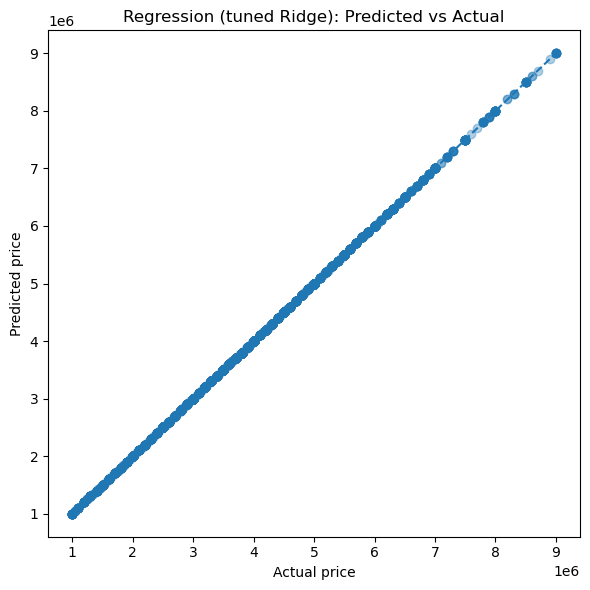

In [22]:
y_true = np.expm1(y_test_reg)
y_pred = np.expm1(pred_test_reg)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.35)
mn = float(min(y_true.min(), y_pred.min()))
mx = float(max(y_true.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Regression (tuned Ridge): Predicted vs Actual")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.tight_layout()
plt.show()


**Nhận xét nhỏ:** Ridge thường dự đoán tốt vùng trung bình; nếu lệch ở vùng cao → có thể thiếu feature “cao cấp” (view/toà nhà/đường/tiện ích chi tiết).


### Classification diagnostic — Confusion Matrix


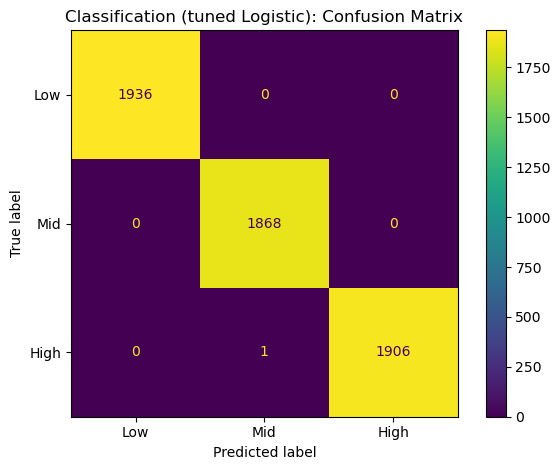

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test_cls, pred_test_cls, labels=labels)
plt.title("Classification (tuned Logistic): Confusion Matrix")
plt.tight_layout()
plt.show()


**Nhận xét nhỏ:** Nếu nhầm nhiều ở Mid↔High: ngưỡng tertile gần nhau hoặc feature chưa đủ phân biệt phân khúc.


## 13) Predict on new data (inference demo)

Demo: lấy 5 dòng từ test và coi như “data mới” (chỉ có features).
Output:
- `pred_price` (regression)
- `pred_segment` + xác suất (classification)


In [24]:
new_data = X_test.sample(5, random_state=7).copy()

pred_price_log = final_reg_model.predict(new_data)
pred_price = np.expm1(pred_price_log)

pred_seg = final_cls_model.predict(new_data)
pred_seg_proba = final_cls_model.predict_proba(new_data)

out = new_data.copy()
out["pred_price"] = pred_price
out["pred_segment"] = pred_seg

proba_df = pd.DataFrame(pred_seg_proba, columns=[f"proba_{c}" for c in labels], index=out.index)
out = pd.concat([out, proba_df], axis=1)

out


,area,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,has_sofa,is_full_furniture,is_duplex,...,washing_machine_type,lock_type,wc_type,water_type,area_group,pred_price,pred_segment,proba_Low,proba_Mid,proba_High
26252,40.0,False,True,False,False,False,False,False,True,False,...,unknown,unknown,unknown,unknown,outer,5.000000e+06,High,1.000000e+00,6.477434e-85,4.142280e-21
23036,25.0,False,False,False,False,False,False,False,True,False,...,unknown,unknown,unknown,bottle,center,5.000000e+06,High,1.000000e+00,3.608804e-85,2.537719e-21
10865,25.0,True,False,True,False,False,False,False,False,False,...,share,unknown,unknown,unknown,south,4.500000e+06,High,9.965080e-01,4.067740e-51,3.492005e-03
22707,40.0,False,False,False,False,False,False,False,True,False,...,unknown,unknown,unknown,unknown,south,3.500000e+06,Mid,1.341607e-41,5.656759e-11,1.000000e+00
13978,25.0,True,False,False,False,False,False,False,True,False,...,unknown,unknown,unknown,unknown,west,3.300000e+06,Mid,1.347242e-51,1.954461e-03,9.980455e-01


**Nhận xét nhỏ:** Đây là output bạn sẽ trả về từ API (web). Linear models phù hợp vì latency thấp.


## 14) Save artifacts (deploy-ready)
- Lưu pipeline regression + pipeline classification + thresholds `q1,q2`


In [ ]:
import joblib, os

artifact_dir = "../../data/model_artifacts_linearfirst"
os.makedirs(artifact_dir, exist_ok=True)

joblib.dump(final_reg_model, os.path.join(artifact_dir, "final_reg_ridge.joblib"))
joblib.dump(final_cls_model, os.path.join(artifact_dir, "final_cls_logreg.joblib"))
joblib.dump({"q1": float(q1), "q2": float(q2), "labels": labels},
            os.path.join(artifact_dir, "price_segment_thresholds.joblib"))

artifact_dir, os.listdir(artifact_dir)


('/mnt/data/model_artifacts_linearfirst',
 ['final_reg_ridge.joblib',
  'final_cls_logreg.joblib',
  'price_segment_thresholds.joblib'])

## 15) Kết luận “ML cho web” (tóm tắt)
- **Linear-first** (Ridge/Logistic) thường cho trade-off tốt nhất: nhanh + ổn định + deploy dễ  
- **Random Search** giúp tìm hyperparameter nhanh trong không gian nhiều chiều; Grid chỉ dùng để refine  
- Với **high-dim** do one-hot: regularization (L2/ElasticNet) + sparse pipeline là chìa khoá  
- Nếu cần mạnh hơn, cân nhắc boosting/NN nhưng luôn kiểm tra latency & footprint trước khi chọn
